# Only All-NBA Teams CLF

## Data analysis, correlation

In [7]:
import pandas as pd

df = pd.read_csv("../databases/nba_dataset_2010_2025.csv")
drop_cols = ["Player", "Team", "Pos", "season",'FG', '3P', '2P', 'FT', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV%', 'is_rookie', 'rookie_of_month_count']


df.drop(columns=drop_cols, inplace=True)

In [16]:
df.columns

Index(['Age', 'G', 'GS', 'MP_avg', 'FGA', 'FG%', '3PA', '3P%', '2PA', '2P%',
       'eFG%', 'FTA', 'FT%', 'TOV', 'PF', 'PTS', 'MP_total', 'PER', 'TS%',
       '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'W', 'L',
       'MOV', 'SOS', 'SRS', 'ORtg', 'DRtg', 'NRtg', 'Pace',
       'Offense Four Factors eFG%', 'Offense Four Factors TOV%',
       'Offense Four Factors ORB%', 'Offense Four Factors FT/FGA',
       'Defense Four Factors eFG%', 'Defense Four Factors TOV%',
       'Defense Four Factors DRB%', 'Defense Four Factors FT/FGA',
       'potw_count', 'potm_count', 'target'],
      dtype='object')

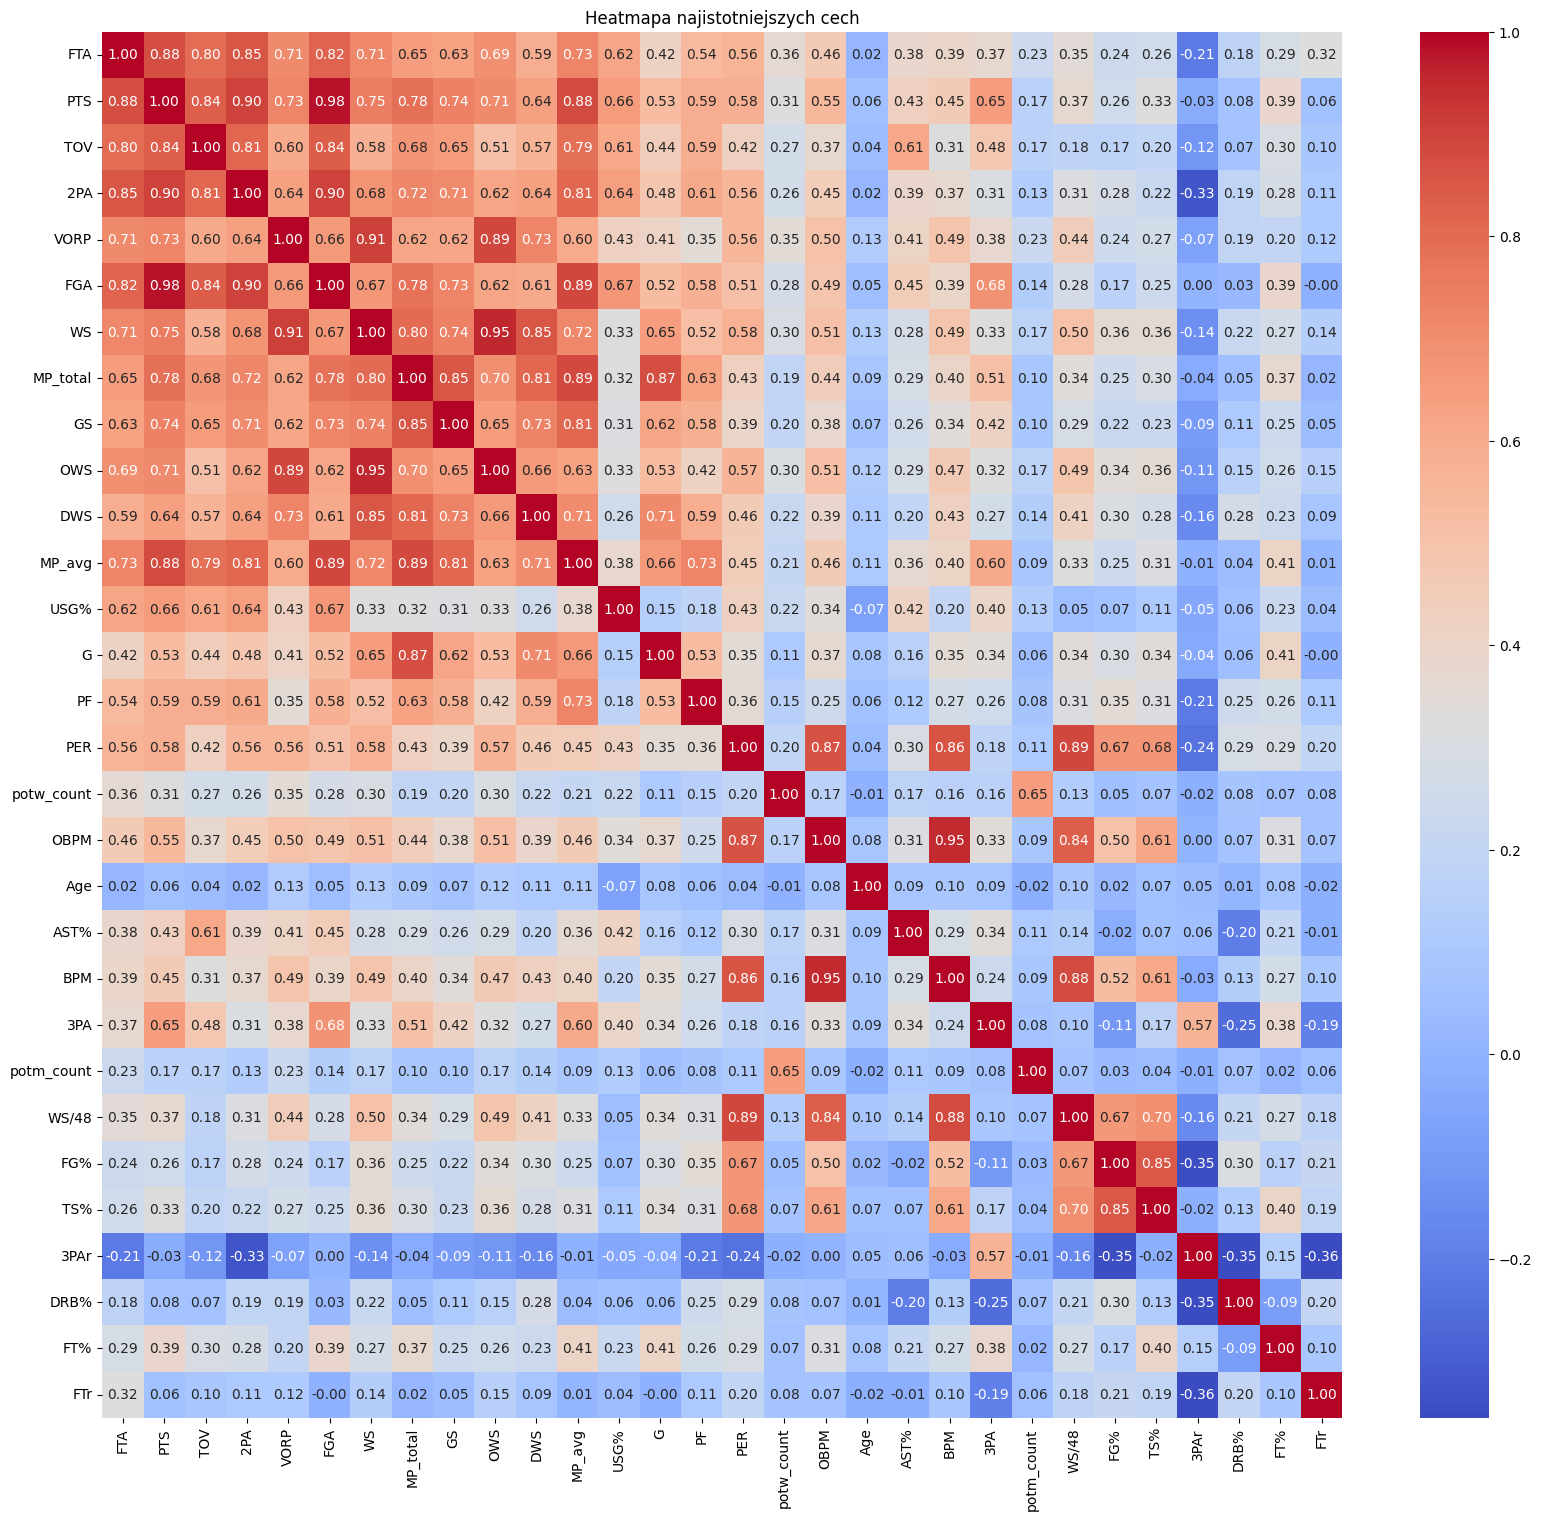

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Oblicz korelację ze zmienną target
correlation_matrix = df.corr()
target_corr = correlation_matrix["target"].drop("target")  # usuń self-korelację

top_features = target_corr.abs().sort_values(ascending=False).head(30).index

# Podzbiór korelacji
reduced_corr = correlation_matrix.loc[top_features, top_features]

# Wizualizacja
plt.figure(figsize=(20, 18))
sns.heatmap(reduced_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmapa najistotniejszych cech")
plt.show()

In [20]:
import pandas as pd
import numpy as np



# Przygotowanie zbioru cech
df["target"] = df["target"].replace({4: 0, 5: 0})
drop_cols = ["target"]
X = df.drop(columns=drop_cols, errors="ignore")

# Funkcja usuwająca cechy o korelacji > threshold
def remove_highly_correlated_features(df, threshold=0.80):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = set()
    for column in upper.columns:
        high_corr = upper[column][upper[column] > threshold].index.tolist()
        if high_corr:
            to_drop.update(high_corr)
    
    return df.drop(columns=to_drop), sorted(to_drop), corr_matrix

# Zastosowanie funkcji
X_cleaned, dropped_features, corr_matrix = remove_highly_correlated_features(X, threshold=0.80)


dropped_features[:10]  # pokaz pierwsze 10 usuniętych cech jako przykład


['2PA', 'DRB%', 'DRtg', 'DWS', 'FG%', 'FGA', 'FTA', 'G', 'GS', 'L']

In [25]:
X_cleaned.columns

Index(['Age', '3PA', '3P%', '2P%', 'FT%', 'PF', 'PTS', 'TS%', '3PAr', 'FTr',
       'TRB%', 'AST%', 'STL%', 'BLK%', 'USG%', 'DBPM', 'BPM', 'VORP', 'SOS',
       'NRtg', 'Pace', 'Offense Four Factors eFG%',
       'Offense Four Factors TOV%', 'Offense Four Factors ORB%',
       'Offense Four Factors FT/FGA', 'Defense Four Factors eFG%',
       'Defense Four Factors TOV%', 'Defense Four Factors DRB%',
       'Defense Four Factors FT/FGA', 'potw_count', 'potm_count'],
      dtype='object')

In [28]:
# Przywrócenie kolumn meta + target do zbioru X_cleaned
meta_columns = ["Player", "Team", "Pos", "season", "target"]
X_cleaned_with_meta = df[meta_columns].join(X_cleaned)


X_cleaned_with_meta.to_csv("databases/nba_dataset_2010_2025_cleaned.csv", index=False)

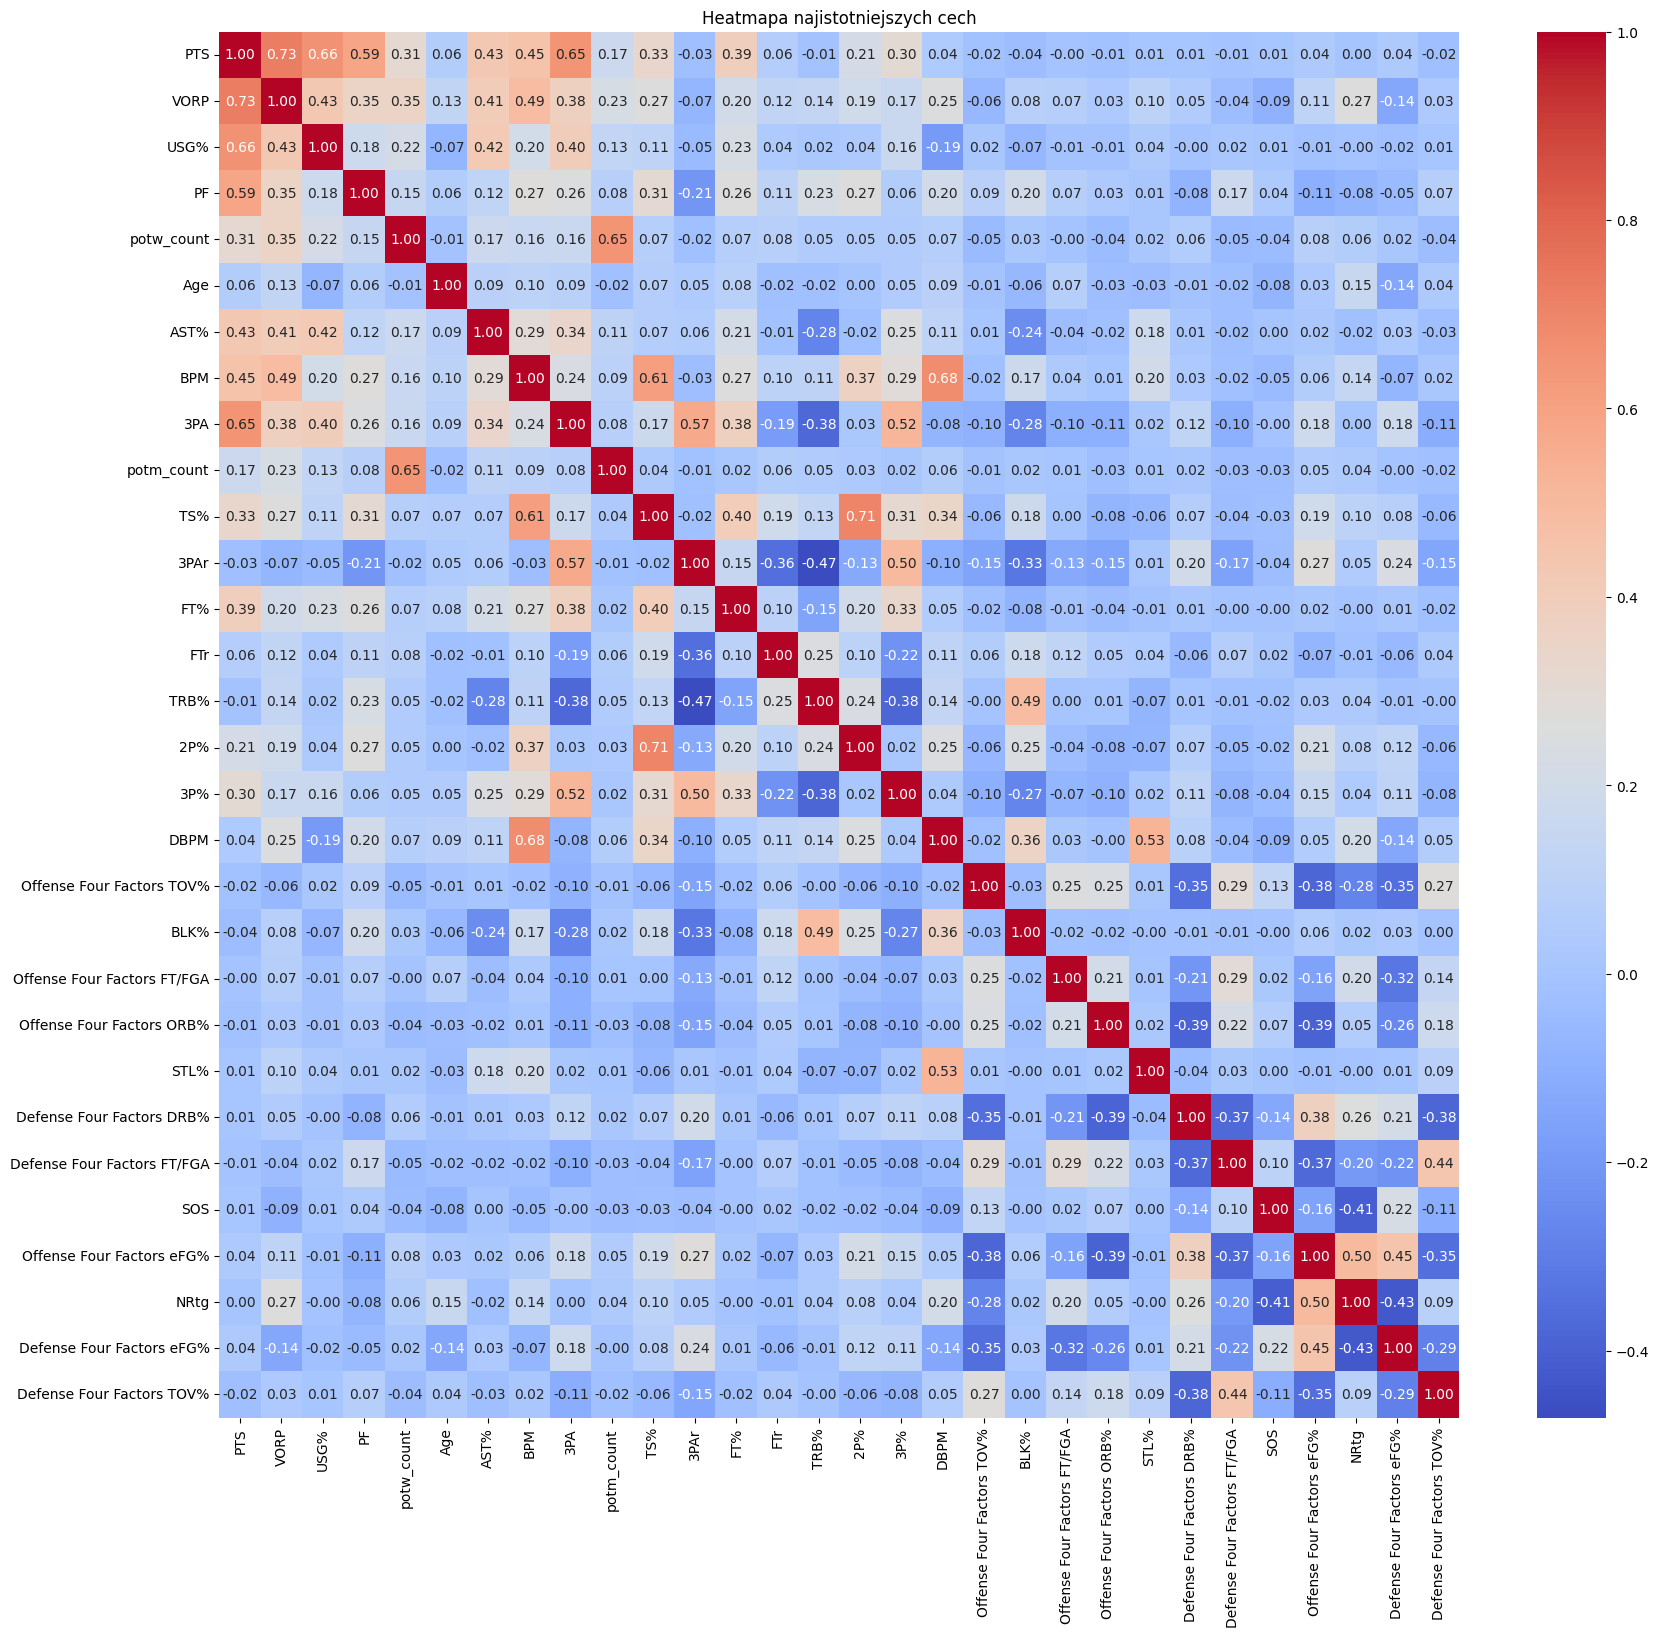

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

X_cleaned_with_meta.drop(columns=["Player", "Team", "Pos", "season"], inplace=True)
correlation_matrix = X_cleaned_with_meta.corr()
target_corr = correlation_matrix["target"].drop("target")  # usuń self-korelację

top_features = target_corr.abs().sort_values(ascending=False).head(30).index

# Podzbiór korelacji
reduced_corr = correlation_matrix.loc[top_features, top_features]

# Wizualizacja
plt.figure(figsize=(20, 18))
sns.heatmap(reduced_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmapa najistotniejszych cech")
plt.show()

## Stage 1: XGB,   Stage 2: Stacking CLF (XGB, GBC) + LR , Params Testing

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

# === 1. Wczytanie danych
df = pd.read_csv("databases/nba_dataset_umap_25.csv")
df["target"] = df["target"].replace({4: 0, 5: 0})  # Zamiana 4 i 5 na 0
df["target_binary"] = (df["target"] > 0).astype(int)

drop_cols = ["Player", "Team", "Pos", "season", "target"]

train_mask = df["season"] < 2025
test_mask = df["season"] == 2025

X_train = df[train_mask].drop(columns=drop_cols)
X_test = df[test_mask].drop(columns=drop_cols)
y_train_bin = df[train_mask]["target_binary"]
y_train_full = df[train_mask]["target"]
players_test = df[test_mask]["Player"].reset_index(drop=True)

# === 2. Stage 1: klasyfikacja binarna
model_bin = XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42)
sample_weight_stage1 = compute_sample_weight("balanced", y_train_bin)
model_bin.fit(X_train, y_train_bin, sample_weight=sample_weight_stage1)
stage1_preds = model_bin.predict(X_test)

# === 3. Dane Stage 2
class_map = {1: 0, 2: 1, 3: 2}
inverse_class_map = {v: k for k, v in class_map.items()}

X_train_stage2 = X_train[y_train_bin == 1]
y_train_stage2 = y_train_full[y_train_bin == 1].map(class_map)
X_test_stage2 = X_test[stage1_preds == 1].reset_index(drop=True)
players_stage2 = players_test[stage1_preds == 1].reset_index(drop=True)

# === 4. Składniki stacking
model_xgb = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss", random_state=42)
model_gbc = GradientBoostingClassifier(random_state=42)
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42
    )
)

stacking_model = StackingClassifier(
    estimators=[
        ("xgb", model_xgb),
        ("gbc", model_gbc)
    ],
    final_estimator=logreg_pipeline,
    stack_method="predict_proba",
    passthrough=False,
    cv=3,
    n_jobs=-1
)

# === 5. Hiperparametry
param_distributions = {
    "final_estimator__logisticregression__C": [0.001, 0.01, 0.1, 1, 5, 10],
    "gbc__n_estimators": [100, 200, 300, 500],
    "gbc__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "gbc__max_depth": [3, 4, 5, 6],
    "gbc__subsample": [0.7, 0.8, 1.0],
    "xgb__n_estimators": [200, 300, 500],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
    "xgb__gamma": [0, 1, 5]
}

search = RandomizedSearchCV(
    estimator=stacking_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# === 6. Trening
search.fit(X_train_stage2, y_train_stage2)
best_model = search.best_estimator_

# === 7. Predykcja
probas_stage2 = best_model.predict_proba(X_test_stage2)



df_pred = pd.DataFrame(probas_stage2, columns=[inverse_class_map[i] for i in range(3)])
df_pred["Player"] = players_stage2

results = {
    "first all-nba team": df_pred.sort_values(1, ascending=False)["Player"].head(5).tolist(),
    "second all-nba team": df_pred.sort_values(2, ascending=False)["Player"].head(5).tolist(),
    "third all-nba team": df_pred.sort_values(3, ascending=False)["Player"].head(5).tolist()
}

# === 8. Zapis JSON
with open("classification_allnba_result_2025.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)




In [11]:
results = {}
ordinal = ["first", "second", "third"]

# All-NBA teams (1st, 2nd, 3rd)
already_selected = set()
for idx, class_id in enumerate([1, 2, 3]):
    available = df_pred[~df_pred["Player"].isin(already_selected)]
    top5 = available.sort_values(class_id, ascending=False).head(5)
    team_name = f"{ordinal[idx]} all-nba team"
    team_players = top5["Player"].tolist()
    results[team_name] = team_players
    already_selected.update(team_players)



# === 7. Zapis do JSON
with open("classification_allnba_result_2025.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


In [12]:
df_pred["all_nba_score"] = df_pred[[1, 2, 3]].sum(axis=1)

top15 = df_pred.sort_values("all_nba_score", ascending=False).head(15).copy()
print("Top 15 graczy sortowanych po all_nba_score:")
print(top15[["Player", 1, "all_nba_score"]])

ranks = {
    "first all-nba team": top15.sort_values(1, ascending=False)["Player"].tolist(),
    "second all-nba team": top15.sort_values(2, ascending=False)["Player"].tolist(),
    "third all-nba team": top15.sort_values(3, ascending=False)["Player"].tolist()
}

results = {team: [] for team in ranks}
used_players = set()

while any(len(results[team]) < 5 for team in results):
    for team in ["first all-nba team", "second all-nba team", "third all-nba team"]:
        for player in ranks[team]:
            if player not in used_players:
                results[team].append(player)
                used_players.add(player)
                break


with open("classification_allnba_result_2025.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


Top 15 graczy sortowanych po all_nba_score:
                     Player         1  all_nba_score
13            Stephen Curry  0.061510            1.0
6            Jalen Williams  0.046340            1.0
7              James Harden  0.283636            1.0
8              Jayson Tatum  0.846907            1.0
14        Tyrese Haliburton  0.021029            1.0
1           Cade Cunningham  0.148508            1.0
3               Evan Mobley  0.018305            1.0
9        Karl-Anthony Towns  0.083850            1.0
12  Shai Gilgeous-Alexander  0.890141            1.0
2          Donovan Mitchell  0.024638            1.0
10             LeBron James  0.067797            1.0
4     Giannis Antetokounmpo  0.817982            1.0
0           Anthony Edwards  0.170788            1.0
5             Jalen Brunson  0.038756            1.0
11             Nikola Jokić  0.879661            1.0


In [92]:
# Zapis pełnych prawdopodobieństw dla graczy z stage2
df_pred_sorted = df_pred.sort_values(by=1, ascending=False)  # możesz też sortować po max(axis=1)
df_pred_sorted.to_csv("stage2_all_players_probs.csv", index=False)

In [93]:
df_pred_sorted1 = df_pred.sort_values(by=1, ascending=False)
df_pred_sorted2 = df_pred.sort_values(by=2, ascending=False)
df_pred_sorted3 = df_pred.sort_values(by=3, ascending=False)

In [94]:
df_pred_sorted1


,1,2,3,Player,all_nba_score
8,0.671715,0.218213,0.110072,Jayson Tatum,1.0
7,0.670252,0.218860,0.110888,James Harden,1.0
4,0.642729,0.237410,0.119861,Giannis Antetokounmpo,1.0
11,0.598170,0.263424,0.138407,Nikola Jokić,1.0
12,0.572418,0.277081,0.150501,Shai Gilgeous-Alexander,1.0
0,0.343370,0.375631,0.280999,Anthony Edwards,1.0
13,0.222840,0.332977,0.444183,Stephen Curry,1.0
9,0.203475,0.334561,0.461963,Karl-Anthony Towns,1.0
2,0.197523,0.327549,0.474928,Donovan Mitchell,1.0
10,0.185607,0.337647,0.476746,LeBron James,1.0


In [95]:
df_pred_sorted2

,1,2,3,Player,all_nba_score
0,0.343370,0.375631,0.280999,Anthony Edwards,1.0
5,0.170796,0.344573,0.484631,Jalen Brunson,1.0
10,0.185607,0.337647,0.476746,LeBron James,1.0
9,0.203475,0.334561,0.461963,Karl-Anthony Towns,1.0
13,0.222840,0.332977,0.444183,Stephen Curry,1.0
2,0.197523,0.327549,0.474928,Donovan Mitchell,1.0
1,0.142850,0.308078,0.549072,Cade Cunningham,1.0
6,0.139316,0.301329,0.559354,Jalen Williams,1.0
3,0.125628,0.291040,0.583332,Evan Mobley,1.0
12,0.572418,0.277081,0.150501,Shai Gilgeous-Alexander,1.0


In [96]:
df_pred_sorted3

,1,2,3,Player,all_nba_score
14,0.119585,0.276828,0.603587,Tyrese Haliburton,1.0
3,0.125628,0.291040,0.583332,Evan Mobley,1.0
6,0.139316,0.301329,0.559354,Jalen Williams,1.0
1,0.142850,0.308078,0.549072,Cade Cunningham,1.0
5,0.170796,0.344573,0.484631,Jalen Brunson,1.0
10,0.185607,0.337647,0.476746,LeBron James,1.0
2,0.197523,0.327549,0.474928,Donovan Mitchell,1.0
9,0.203475,0.334561,0.461963,Karl-Anthony Towns,1.0
13,0.222840,0.332977,0.444183,Stephen Curry,1.0
0,0.343370,0.375631,0.280999,Anthony Edwards,1.0


## PCA

In [8]:
X = df.drop(columns=["Player", "Team", "Pos", "season", "target", "is_rookie", 'rookie_of_month_count'], errors="ignore")

In [9]:
len(X.columns)

55

In [10]:
X.columns

Index(['Age', 'G', 'GS', 'MP_avg', 'FGA', 'FG%', '3PA', '3P%', '2PA', '2P%',
       'eFG%', 'FTA', 'FT%', 'TOV', 'PF', 'PTS', 'MP_total', 'PER', 'TS%',
       '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'USG%',
       'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'W', 'L',
       'MOV', 'SOS', 'SRS', 'ORtg', 'DRtg', 'NRtg', 'Pace',
       'Offense Four Factors eFG%', 'Offense Four Factors TOV%',
       'Offense Four Factors ORB%', 'Offense Four Factors FT/FGA',
       'Defense Four Factors eFG%', 'Defense Four Factors TOV%',
       'Defense Four Factors DRB%', 'Defense Four Factors FT/FGA',
       'potw_count', 'potm_count'],
      dtype='object')

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Standaryzacja
X = df.drop(columns=["Player", "Team", "Pos", "season", "target", "is_rookie", 'rookie_of_month_count'], errors="ignore")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_pca = PCA(n_components=20)
x_pca_transformed = x_pca.fit_transform(X_scaled)

# Udział wariancji
explained_variance = x_pca.explained_variance_ratio_
variance_df = pd.DataFrame({
    "Składowa": [f'PC{i+1}' for i in range(len(explained_variance))],
    "Wariancja [%]": explained_variance * 100
})
# Wyświetl wyniki
print("Wariancja wyjaśniona przez każdą składową PCA:")
print(variance_df)


Wariancja wyjaśniona przez każdą składową PCA:
   Składowa  Wariancja [%]
0       PC1      28.159212
1       PC2      10.760592
2       PC3      10.071327
3       PC4       7.774942
4       PC5       5.676856
5       PC6       3.451213
6       PC7       2.989997
7       PC8       2.499193
8       PC9       2.224318
9      PC10       2.147087
10     PC11       1.783572
11     PC12       1.690889
12     PC13       1.595390
13     PC14       1.491734
14     PC15       1.394843
15     PC16       1.351067
16     PC17       1.252551
17     PC18       1.147948
18     PC19       1.091538
19     PC20       1.005839


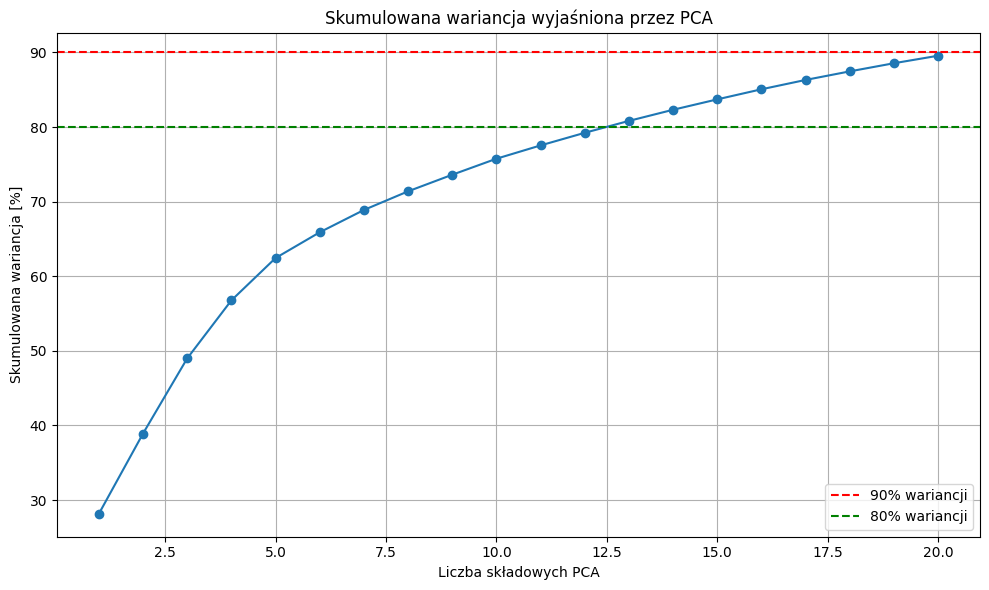

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Obliczenie skumulowanej wariancji
cumulative_variance = np.cumsum(x_pca.explained_variance_ratio_) * 100

# Wykres
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.axhline(y=90, color='r', linestyle='--', label='90% wariancji')
plt.axhline(y=80, color='g', linestyle='--', label='80% wariancji')
plt.xlabel("Liczba składowych PCA")
plt.ylabel("Skumulowana wariancja [%]")
plt.title("Skumulowana wariancja wyjaśniona przez PCA")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Przygotowanie DataFrame z 20 składowymi PCA
pca_columns = [f'PC{i+1}' for i in range(20)]
X_pca_20 = pd.DataFrame(x_pca_transformed[:, :20], columns=pca_columns)

# Dołączenie kolumn meta
meta_cols = ["Player", "Team", "Pos", "season", "target"]
final_df = pd.concat([df[meta_cols].reset_index(drop=True), X_pca_20.reset_index(drop=True)], axis=1)


In [8]:
final_df.columns

Index(['Player', 'Team', 'Pos', 'season', 'target', 'PC1', 'PC2', 'PC3', 'PC4',
       'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13',
       'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20'],
      dtype='object')

In [9]:
final_df.to_csv("databases/nba_dataset_2010_2025_pca20.csv", index=False)

## UMAP 

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

# === Wczytanie danych
df = pd.read_csv("databases/nba_dataset_2010_2025.csv")

# === Przygotowanie cech (X)
X = df.drop(columns=["Player", "Team", "Pos", "season", "target"], errors="ignore")

# === Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Redukcja UMAP do 25 wymiarów
reducer = umap.UMAP(n_components=25, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# === Tworzenie finalnego DataFrame
umap_columns = [f"UMAP_{i+1}" for i in range(25)]
X_umap_df = pd.DataFrame(X_umap, columns=umap_columns)
final_df = pd.concat([df[["Player", "Team", "Pos", "season", "target"]].reset_index(drop=True),
                      X_umap_df.reset_index(drop=True)], axis=1)

# === Zapis do pliku
final_df.to_csv("databases/nba_dataset_umap_25.csv", index=False)
print("Gotowe: zapisano do 'nba_dataset_umap_25.csv'")

## Voting CLF with Stacking Classifier, XGB solo - Params Tuning, Prediction

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

# === 1. Wczytanie danych
df = pd.read_csv("databases/nba_dataset_2010_2025_pca20.csv")
df["target"] = df["target"].replace({4: 0, 5: 0})  # Zamiana 4 i 5 na 0
df["target_binary"] = (df["target"] > 0).astype(int)

drop_cols = ["Player", "Team", "Pos", "season", "target"]

train_mask = df["season"] < 2025
test_mask = df["season"] == 2025

X_train = df[train_mask].drop(columns=drop_cols)
X_test = df[test_mask].drop(columns=drop_cols)
y_train_bin = df[train_mask]["target_binary"]
y_train_full = df[train_mask]["target"]
players_test = df[test_mask]["Player"].reset_index(drop=True)

# === 2. Stage 1: klasyfikacja binarna
model_bin = XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42)
sample_weight_stage1 = compute_sample_weight("balanced", y_train_bin)
model_bin.fit(X_train, y_train_bin, sample_weight=sample_weight_stage1)
stage1_preds = model_bin.predict(X_test)

# === 3. Dane Stage 2
class_map = {1: 0, 2: 1, 3: 2}
inverse_class_map = {v: k for k, v in class_map.items()}

X_train_stage2 = X_train[y_train_bin == 1]
y_train_stage2 = y_train_full[y_train_bin == 1].map(class_map)
X_test_stage2 = X_test[stage1_preds == 1].reset_index(drop=True)
players_stage2 = players_test[stage1_preds == 1].reset_index(drop=True)

# === 4. Składniki stackingu
model_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

model_gbc = GradientBoostingClassifier(random_state=42)

logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42
    )
)

stacking_model = StackingClassifier(
    estimators=[
        ("xgb", model_xgb),
        ("gbc", model_gbc)
    ],
    final_estimator=logreg_pipeline,
    stack_method="predict_proba",
    passthrough=False,
    cv=3,
    n_jobs=-1
)

# === 5. RandomizedSearchCV na stackingu
param_distributions = {
    "final_estimator__logisticregression__C": [0.001, 0.01, 0.1, 1, 5, 10],
    "gbc__n_estimators": [100, 200, 300, 500],
    "gbc__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "gbc__max_depth": [3, 4, 5, 6],
    "gbc__subsample": [0.7, 0.8, 1.0],
    "xgb__n_estimators": [200, 300, 500],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__colsample_bytree": [0.7, 0.9, 1.0],
    "xgb__gamma": [0, 1, 5]
}

search = RandomizedSearchCV(
    estimator=stacking_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_stage2, y_train_stage2)
best_stack = search.best_estimator_

# === 6. Niezależny model: XGBClassifier
model_xgb_solo = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_xgb_solo.fit(X_train_stage2, y_train_stage2)

# === 7. VotingClassifier (stacking + XGB)
voting_combo = VotingClassifier(
    estimators=[
        ("stacking", best_stack),
        ("xgb_solo", model_xgb_solo)
    ],
    voting="soft",
    weights=[2, 1]  # większe zaufanie do stackingu
)

voting_combo.fit(X_train_stage2, y_train_stage2)
probas_stage2 = voting_combo.predict_proba(X_test_stage2)

# === 8. Tworzenie piątek

df_pred = pd.DataFrame(probas_stage2, columns=[inverse_class_map[i] for i in range(3)])
df_pred["Player"] = players_stage2


results = {
    "first all-nba team": df_pred.sort_values(1, ascending=False)["Player"].head(5).tolist(),
    "second all-nba team": df_pred.sort_values(2, ascending=False)["Player"].head(5).tolist(),
    "third all-nba team": df_pred.sort_values(3, ascending=False)["Player"].head(5).tolist(),
}

# === 9. Zapis JSON
with open("classification_allnba_result_2025.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)



In [50]:

search.get_params

<bound method BaseEstimator.get_params of RandomizedSearchCV(cv=3,
                   estimator=StackingClassifier(cv=3,
                                                estimators=[('xgb',
                                                             XGBClassifier(base_score=None,
                                                                           booster=None,
                                                                           callbacks=None,
                                                                           colsample_bylevel=None,
                                                                           colsample_bynode=None,
                                                                           colsample_bytree=None,
                                                                           device=None,
                                                                           early_stopping_rounds=None,
                                                     

In [51]:
best_stack.get_params()

{'cv': 3,
 'estimators': [('xgb',
   XGBClassifier(base_score=None, booster=None, callbacks=None,
                 colsample_bylevel=None, colsample_bynode=None,
                 colsample_bytree=0.9, device=None, early_stopping_rounds=None,
                 enable_categorical=False, eval_metric='mlogloss',
                 feature_types=None, feature_weights=None, gamma=1,
                 grow_policy=None, importance_type=None,
                 interaction_constraints=None, learning_rate=0.05, max_bin=None,
                 max_cat_threshold=None, max_cat_to_onehot=None,
                 max_delta_step=None, max_depth=4, max_leaves=None,
                 min_child_weight=None, missing=nan, monotone_constraints=None,
                 multi_strategy=None, n_estimators=200, n_jobs=None, num_class=5, ...)),
  ('gbc',
   GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=500,
                              random_state=42, subsample=0.7))],
 'final_estimator__memory':